# Data & Packages

In [1]:
# Packages 
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
# Time constants
seconds_in_day = 60 * 60 * 24 
minutes_per_week = 7 * 24 * 60 
n_weeks = 8     
eight_weeks_seconds = n_weeks * minutes_per_week * 60

In [3]:
# Load data and filter for human users & first 8 weeks of data
df = (
    pl.scan_csv("/home/lanl/data/cyber1/auth.txt.gz", has_header=False, separator=",",
                new_columns=['time','src_user','dest_user','src_comp','dest_comp',
                              'auth_type','logon_type','auth_orientation','outcome'])
    .filter(pl.col('src_user').str.starts_with('U'))
    .filter(pl.col('time') < eight_weeks_seconds)
    .collect(engine='streaming')
)

# Number of Authentication Events

In [6]:
# Total auth events per user
events_per_user = (
    df
    .group_by("src_user")
    .agg(total_events=pl.len())
)

auth_counts = events_per_user["total_events"].to_numpy()

Text(0, 0.5, 'Frequency')

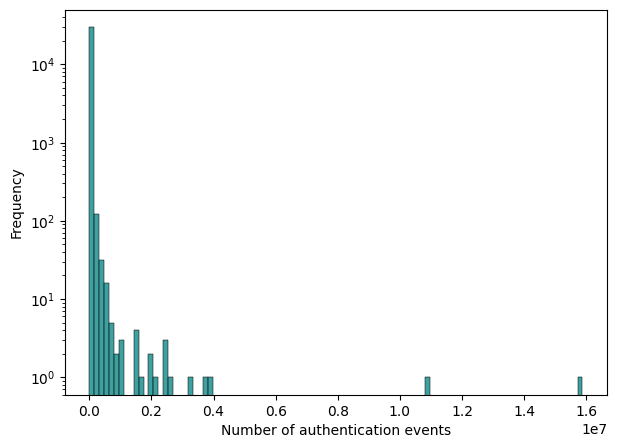

In [7]:
# Distribution of auth events per user
fig, ax = plt.subplots(figsize=(7, 5))

sns.histplot(auth_counts, bins = 100, color='teal')
ax.set_yscale('log')
plt.xlabel('Number of authentication events')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

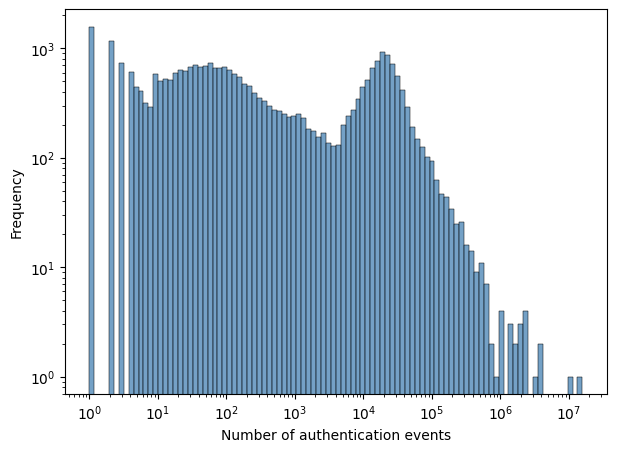

In [8]:
# Distribution of auth events per user (log-scale)
fig, ax = plt.subplots(figsize=(7, 5))

sns.histplot(auth_counts, log_scale=True, bins = 100, color = 'steelblue')
ax.set_yscale('log')
plt.xlabel('Number of authentication events')
plt.ylabel('Frequency')

# Number of Distinct Source Computers

In [9]:
# Number of distinct source computers per user
distinct_src_comps = (
    df
    .group_by('src_user')
    .agg(total = pl.col('src_comp').n_unique())
)

src_comp_counts = distinct_src_comps["total"].to_numpy()

Text(0, 0.5, 'Frequency')

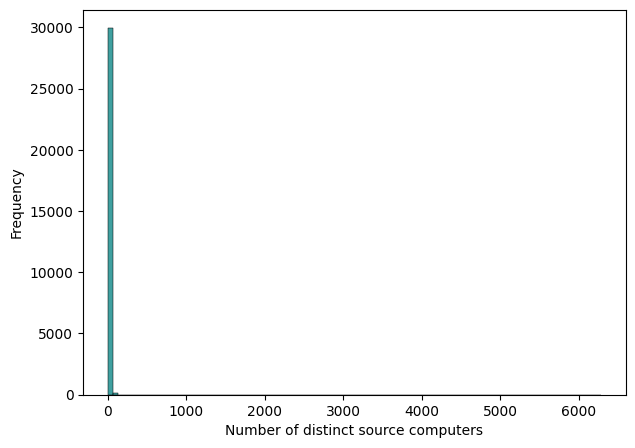

In [10]:
# Distribution of distinct source computers per user
fig, ax = plt.subplots(figsize=(7, 5))

sns.histplot(src_comp_counts, bins = 100, color = 'teal')
plt.xlabel('Number of distinct source computers')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

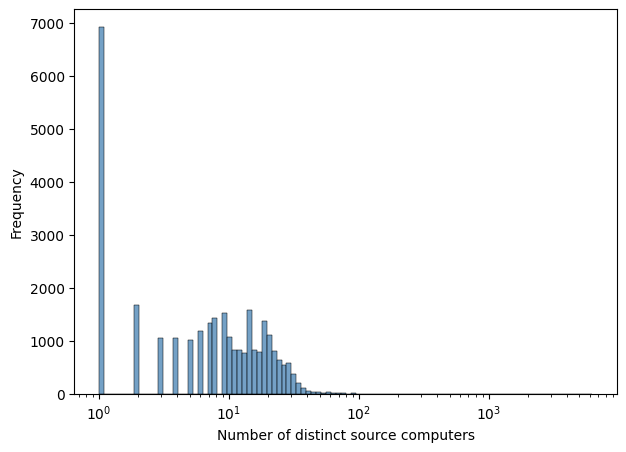

In [11]:
# Distribution of distinct source computers per user (log-scale)
fig, ax = plt.subplots(figsize=(7, 5))

sns.histplot(src_comp_counts, log_scale=True, bins = 100, color = 'steelblue')
plt.xlabel('Number of distinct source computers')
plt.ylabel('Frequency')

# Number of Distinct Destination Computers

In [12]:
# Number of distinct destination computers per user
distinct_dest_comps = (
    df
    .group_by('src_user')
    .agg(total = pl.col('dest_comp').n_unique())
)

dest_comp_counts = distinct_dest_comps["total"].to_numpy()

Text(0, 0.5, 'Frequency')

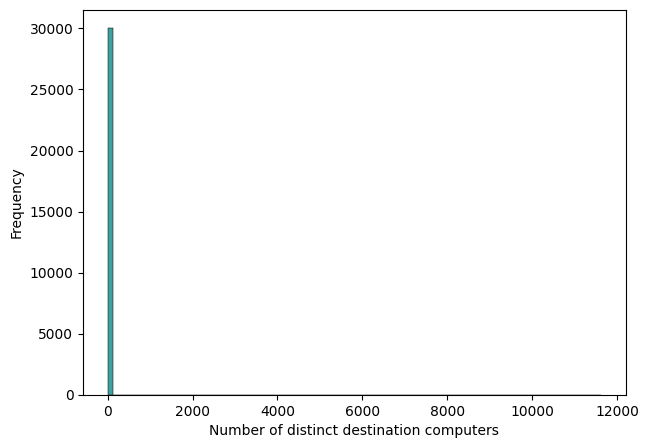

In [13]:
# Distribution of distinct destination computers per user
fig, ax = plt.subplots(figsize=(7, 5))

sns.histplot(dest_comp_counts, bins = 100, color = 'teal')
plt.xlabel('Number of distinct destination computers')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

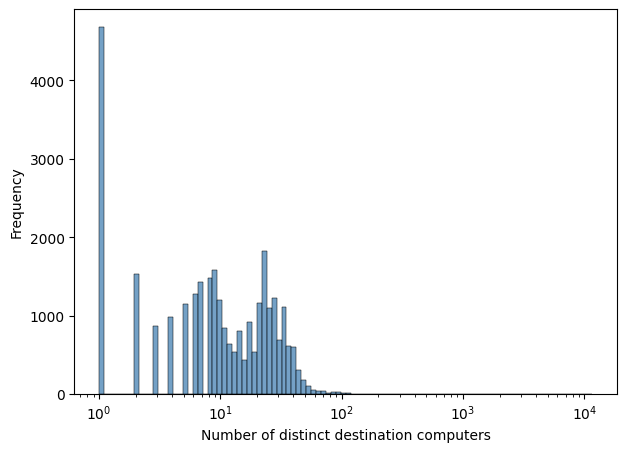

In [14]:
# Distribution of distinct destination computers per user (log-scale)
fig, ax = plt.subplots(figsize=(7, 5))

sns.histplot(dest_comp_counts, log_scale=True, bins = 100, color = 'steelblue')
plt.xlabel('Number of distinct destination computers')
plt.ylabel('Frequency')

## Not used - number of distinct destination users

In [15]:
# Number of distinct destination users per user
distinct_dest_users = (
    df
    .group_by('src_user')
    .agg(total = pl.col('dest_user').n_unique())
)

dest_user_counts = distinct_dest_users["total"].to_numpy()

Text(0, 0.5, 'Frequency')

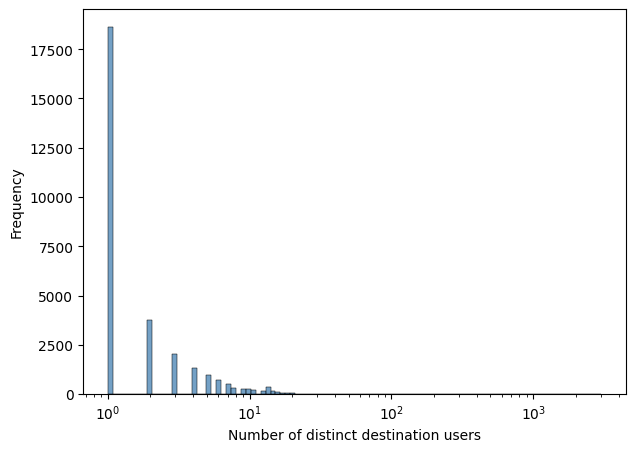

In [16]:
# Distribution of distinct destination users per user
fig, ax = plt.subplots(figsize=(7, 5))

sns.histplot(dest_user_counts, log_scale=True, bins = 100, color = 'steelblue')
plt.xlabel('Number of distinct destination users')
plt.ylabel('Frequency')

# Failure Ratio

In [17]:
# Failure rates per user
user_failures = (
    df
    .with_columns(is_fail = pl.col("outcome") == "Fail")
    .group_by("src_user")
    .agg(failure_rate = pl.col("is_fail").mean())
)

failure_rates = user_failures["failure_rate"].to_numpy()

Text(0, 0.5, 'Frequency')

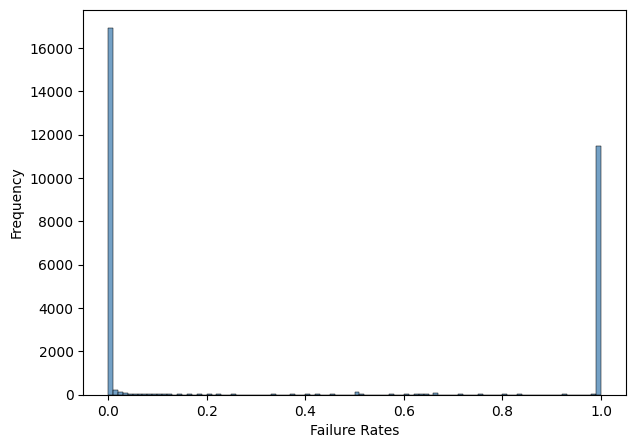

In [18]:
# Distribution of failure rates per user
fig, ax = plt.subplots(figsize=(7, 5))

sns.histplot(failure_rates, bins = 100, color = 'steelblue')
plt.xlabel('Failure Rates')
plt.ylabel('Frequency')

# Time

In [ ]:
# Convert time to radians for circular histogram
df = df.with_columns(
        theta=(pl.col("time") % seconds_in_day) / seconds_in_day * 2 * np.pi,
)

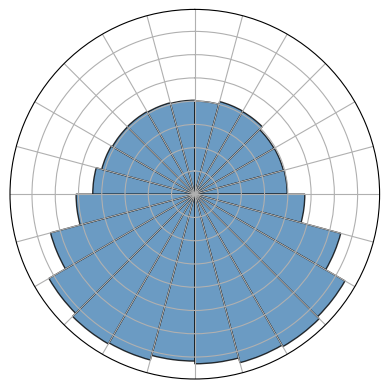

In [40]:
# Distribution of auth events per user by time of day 
n_bins = 24
width = (2 * np.pi)/n_bins

rose = (df
        .with_columns(bin = (pl.col('theta') / width).floor().cast(pl.Int32))
        .with_columns(bin = pl.col('bin') % n_bins)
        .group_by('bin')
        .agg(count = pl.len())
)

counts = np.zeros(n_bins)
counts[rose['bin'].to_numpy()] = rose['count'].to_numpy()

centres = (np.arange(n_bins) + 0.5) * width

fig, ax = plt.subplots(subplot_kw={"projection": "polar"})
ax.bar(centres, counts, width=width, bottom=0.0,
       align="center", edgecolor="k", alpha=0.8, color = 'steelblue')

ax.set_theta_zero_location("N")   
ax.set_theta_direction(-1)        
ax.set_xticks(np.arange(24) / 24 * 2 * np.pi)
ax.set_xticklabels([])
ax.set_yticklabels([])

plt.show()